In [1]:
import torch
from torchvision.transforms import *

from dataset.InterHand26M import InterHand26M

Fix shapedirs bug of MANO


In [2]:
transforms_train = transforms.Compose([
    transforms.Resize((224, 224))
])
dataset = InterHand26M(transforms_train, "test") 

loading annotations into memory...
Done (t=35.33s)
creating index...
index created!


In [4]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=4)

In [11]:
from tqdm import tqdm

data_iter = iter(dataloader)
for _ in tqdm(range(100), ncols=50):
    batch = next(data_iter)

100%|███████████| 100/100 [00:18<00:00,  5.38it/s]


In [15]:
inputs_, targets_, meta_info_ = batch
targets_['mano_pose'].shape

torch.Size([4, 96])

In [19]:
img = torch.randn(3, 100, 100)
transforms_train(img[:,1:1,1:1]).shape

RuntimeError: Input and output sizes should be greater than 0, but got input (H: 0, W: 0) output (H: 224, W: 224)

In [11]:
import cv2
import kornia
import einops
import matplotlib.pyplot as plt

import numpy as np
import torch
import torchvision.transforms as transforms

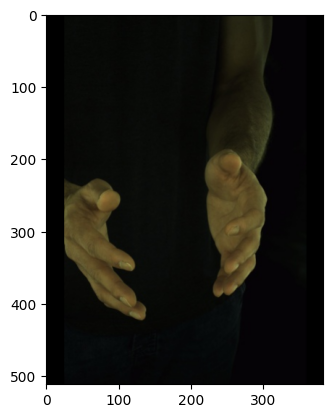

In [9]:
transform = transforms.ToTensor()
img_cv = cv2.imread("frame.png")
plt.imshow(img_cv)

img = transform(img_cv)

In [35]:
def crop_img(img: torch.Tensor,
             bbox_center,
             bbox_size):
    w_center, h_center = bbox_center
    width, height = bbox_size
    w_min = (w_center - width / 2)
    h_min = (h_center - height / 2)
    w_max = (w_center + width / 2)
    h_max = (h_center + height / 2)
    boxes = torch.tensor([[
        # [h_min, w_min], [h_min, w_max], [h_max, w_max], [h_max, w_min]
        [w_min, h_min], [w_max, h_min], [w_max, h_max], [w_min, h_max]
    ]])
    output_size = (int(height), int(width))

    cropped_img = kornia.geometry.transform.crop_and_resize(img[None,...], boxes, output_size)
    return cropped_img[0]

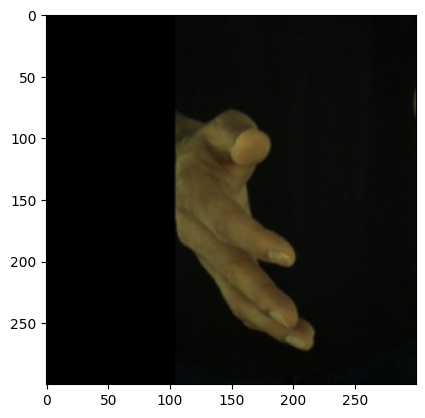

In [38]:
bbox_center = np.array([70, 300], dtype=np.float32)
bbox_size = np.array([300, 300], dtype=np.float32)

cropped_img = crop_img(img, bbox_center, bbox_size)
plt.imshow(einops.rearrange(cropped_img, 'c h w -> h w c'))
plt.show()